In [1]:
# 11.4 Q2 - Identify the Principal Component

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('datasets/variable_table.csv')
print(df)
print()
print("Shape:", df.shape)

         Variable    PC1    PC2    PC3
0         Climate  0.190  0.017  0.207
1         Housing  0.544  0.020  0.204
2          Health  0.782 -0.605  0.144
3           Crime  0.365  0.294  0.585
4  Transportation  0.585  0.085  0.234
5       Education  0.394 -0.273  0.027
6            Arts  0.985  0.126 -0.111
7      Recreation  0.520  0.402  0.519
8         Economy  0.142  0.150  0.239

Shape: (9, 4)


In [4]:
# Variable with highest absolute loading on PC1

In [5]:
df['abs_PC1'] = df['PC1'].abs()
top = df.sort_values('abs_PC1', ascending=False)
print(top)

principal_variable = top.iloc[0]['Variable']
print()
print("Variable with highest |loading on PC1| =", principal_variable)
print("  PC1 loading =", top.iloc[0]['PC1'])

         Variable    PC1    PC2    PC3  abs_PC1
6            Arts  0.985  0.126 -0.111    0.985
2          Health  0.782 -0.605  0.144    0.782
4  Transportation  0.585  0.085  0.234    0.585
1         Housing  0.544  0.020  0.204    0.544
7      Recreation  0.520  0.402  0.519    0.520
5       Education  0.394 -0.273  0.027    0.394
3           Crime  0.365  0.294  0.585    0.365
0         Climate  0.190  0.017  0.207    0.190
8         Economy  0.142  0.150  0.239    0.142

Variable with highest |loading on PC1| = Arts
  PC1 loading = 0.985


In [6]:
# Visualise the loadings

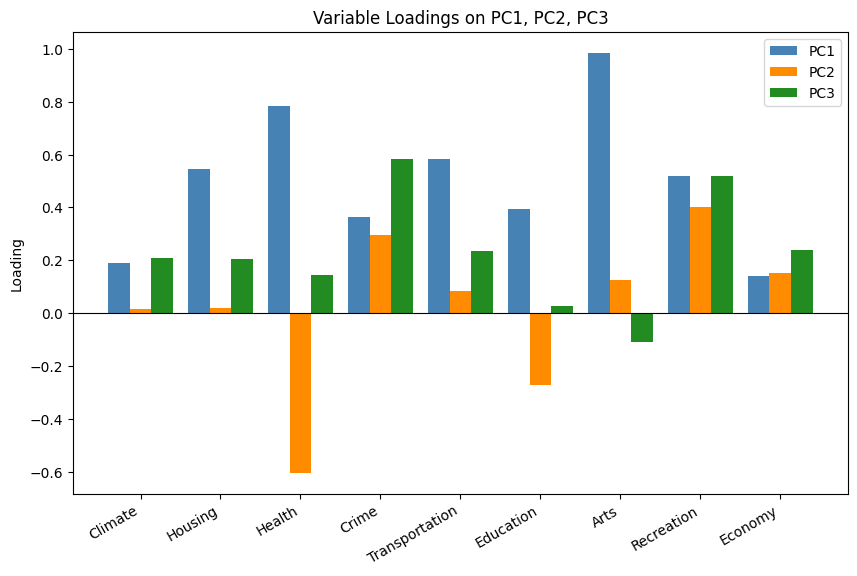

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df))
w = 0.27
ax.bar(x - w, df['PC1'], w, label='PC1', color='steelblue')
ax.bar(x,     df['PC2'], w, label='PC2', color='darkorange')
ax.bar(x + w, df['PC3'], w, label='PC3', color='forestgreen')
ax.set_xticks(x)
ax.set_xticklabels(df['Variable'], rotation=30, ha='right')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Loading')
ax.set_title('Variable Loadings on PC1, PC2, PC3')
ax.legend()
plt.show()

In [8]:
# Magnitude (L2 norm) of each variable's loading vector

         Variable    PC1    PC2    PC3  abs_PC1   L2_norm
6            Arts  0.985  0.126 -0.111    0.985  0.999211
2          Health  0.782 -0.605  0.144    0.782  0.999142
7      Recreation  0.520  0.402  0.519    0.520  0.837475
3           Crime  0.365  0.294  0.585    0.365  0.749591
4  Transportation  0.585  0.085  0.234    0.585  0.635772
1         Housing  0.544  0.020  0.204    0.544  0.581336
5       Education  0.394 -0.273  0.027    0.394  0.480098
8         Economy  0.142  0.150  0.239    0.142  0.315888
0         Climate  0.190  0.017  0.207    0.190  0.281492


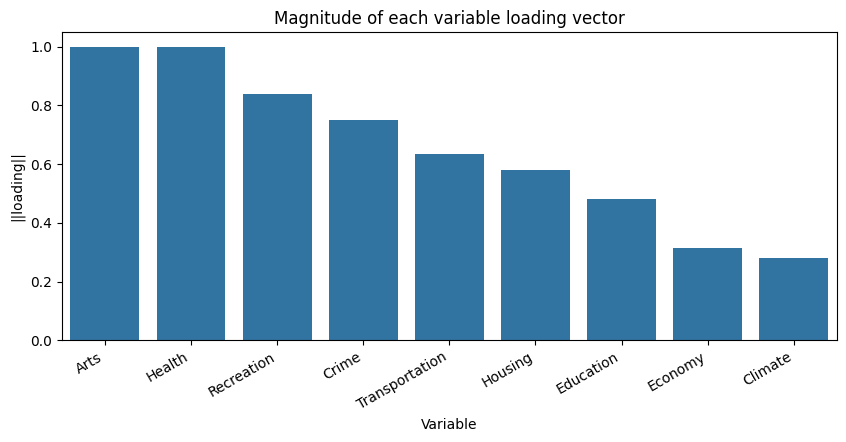

In [9]:
df['L2_norm'] = np.sqrt(df['PC1']**2 + df['PC2']**2 + df['PC3']**2)
print(df.sort_values('L2_norm', ascending=False))

plt.figure(figsize=(10, 4))
sns.barplot(x='Variable', y='L2_norm',
            data=df.sort_values('L2_norm', ascending=False))
plt.xticks(rotation=30, ha='right')
plt.ylabel('||loading||')
plt.title('Magnitude of each variable loading vector')
plt.show()